# Unit 3 / Chapter 3: Quantum Machine Learning

> **Main Learning Objective:** Build actual quantum machine-learning models from scratch: parameterized quantum circuits, variational classifiers, quantum neural networks, and quantum kernel methods. By the end, you will have trained each of these on a small dataset and seen what each is good and bad at.

| Section | Topic | Why it matters for AI |
|---|---|---|
| 3.1 | Hybrid Quantum-Classical Learning | The dominant near-term QML paradigm |
| 3.2 | Variational Quantum Classifiers | Quantum models that learn like neural nets |
| 3.3 | Quantum Neural Networks | The quantum analog of deep learning |
| 3.4 | Quantum Kernel Models | Quantum-enhanced SVM and similarity learning |

By the end of this unit you should be able to:

1. Describe the hybrid quantum-classical training loop in your own words.
2. Build a small parameterized quantum circuit and tune its parameters.
3. Explain how a VQC works as a classifier.
4. State what makes a neural network "quantum."
5. Compute a quantum kernel matrix on a small dataset and use it for classification.

---

# Chapter 3: Quantum Machine Learning



In [1]:
# Verify libraries - works in classic Jupyter, JupyterLite/Pyodide, and Colab.
import importlib.util
required = ["numpy", "matplotlib"]
missing = [p for p in required if importlib.util.find_spec(p) is None]
if missing:
    try:
        import piplite
        await piplite.install(missing)
    except ImportError:
        try:
            import micropip
            await micropip.install(missing)
        except ImportError:
            ip = get_ipython()
            ip.run_line_magic('pip', 'install --quiet ' + ' '.join(missing))
import numpy, matplotlib
print("All libraries ready.")

All libraries ready.


---
## Course check-in

This logs that you started **Unit 3**. You will be asked to enter the email you signed up with so we can track your progress and email your certificate when you finish all units.

In [ ]:
# ============================================================
# COURSE TRACKING - do not edit
# ============================================================
import json
from urllib.request import Request, urlopen
from urllib.error  import URLError

UNIT_NUMBER = 3
TRACKER_URL = "https://script.google.com/macros/s/AKfycbyp01BDLgzqHk5HbYt7Tl0hYESKo4qRs8AMJsFKUfbNKdbUuzjT6yb1L2qVFd_oz2Ur/exec"

def _post_event(event_type, payload=None):
    body = json.dumps({
        "event_type": event_type,
        "email":      _student_email,
        "unit":       UNIT_NUMBER,
        "payload":    payload or {}
    }).encode("utf-8")
    try:
        req = Request(TRACKER_URL, data=body,
                      headers={"Content-Type": "text/plain;charset=utf-8"})
        urlopen(req, timeout=10).read()
    except URLError as e:
        print("(could not reach tracker:", e, ")")

_student_email = input("Enter the email you signed up with: ").strip().lower()
if "@" not in _student_email:
    raise ValueError("That does not look like a valid email. Re-run this cell.")

print(f"Hi {_student_email}! Logging that you started Unit {UNIT_NUMBER}.")
_post_event("unit_started")

In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display, Markdown
import math, cmath, random
np.random.seed(7); random.seed(7)
plt.rcParams['figure.dpi'] = 100

# ---- Tiny quantum simulator we'll reuse all chapter ----
def ket0(n):
    """|0...0> for n qubits."""
    s = np.zeros(2**n, dtype=complex); s[0] = 1.0
    return s

def kron_all(mats):
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
H  = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)

def Rx(t):  c,s = np.cos(t/2), np.sin(t/2); return np.array([[c,-1j*s],[-1j*s,c]], dtype=complex)
def Ry(t):  c,s = np.cos(t/2), np.sin(t/2); return np.array([[c,-s],[s,c]],          dtype=complex)
def Rz(t):  return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]], dtype=complex)

def apply_1q(gate, qubit, n):
    """Embed a 1-qubit gate at `qubit` in an n-qubit register."""
    mats = [gate if i==qubit else I2 for i in range(n)]
    return kron_all(mats)

def apply_cnot(control, target, n):
    """CNOT operator on n qubits."""
    dim = 2**n
    op = np.zeros((dim, dim), dtype=complex)
    for x in range(dim):
        bits = [(x >> (n-1-i)) & 1 for i in range(n)]
        if bits[control] == 1:
            bits[target] ^= 1
        y = 0
        for b in bits:
            y = (y<<1) | b
        op[y, x] = 1
    return op

print("Quantum simulator ready.")

Quantum simulator ready.


---
# Section 3.1-Hybrid Quantum-Classical Learning

## Why hybrid?

Near-term quantum computers are **noisy and shallow**- they can run only a few hundred gates before errors swamp the signal. We can't yet run a giant pure-quantum learning algorithm. So researchers came up with a *workaround*: keep the deep math on the **classical** side, and use the quantum computer only for the part it's actually good at.

That's the **hybrid quantum-classical loop**:

```
        ┌──────────────────────────────┐
        │   Classical optimizer        │
        │ (Adam, SGD, COBYLA, …)       │
        └──────────────┬───────────────┘
                       │  new parameters θ
                       ▼
        ┌──────────────────────────────┐
        │   Parameterized Quantum      │
        │   Circuit  U(θ)              │
        │   prepare → rotate → measure │
        └──────────────┬───────────────┘
                       │  loss value
                       ▼
                  (loop until small)
```

A **Parameterized Quantum Circuit (PQC)** , also called an *ansatz*, is a quantum circuit with knobs. Concretely, it's a sequence of gates where some rotation angles are *trainable parameters* θ that a classical optimizer adjusts to minimize a cost function.

Think of the PQC as a quantum analog of a neural network layer: weights live in the rotation angles, the input is encoded in the initial state, and the output is whatever you measure.

### Anatomy of a parameterized quantum circuit

A typical PQC has three pieces:

1. **Feature map**- encode classical data x into a quantum state |ψ(x)⟩.
2. **Variational ansatz**- a series of trainable rotations and entangling gates U(θ).
3. **Measurement**- read out an expectation value like ⟨Z⟩ that becomes the model's prediction.

Below is a hand-drawn schematic of a 2-qubit PQC.

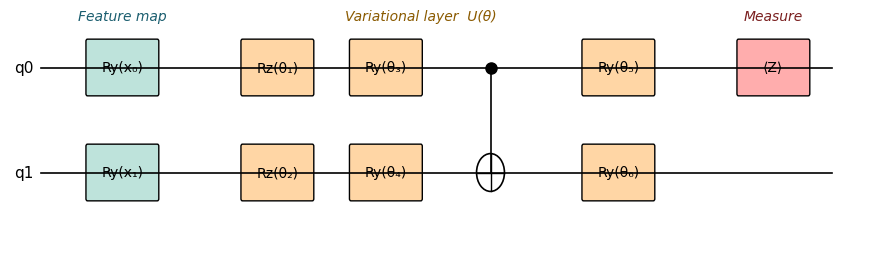

In [3]:
# Schematic of a 2-qubit PQC
fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 11); ax.set_ylim(-0.5, 1.7); ax.axis('off')

# qubit wires
for y, lbl in [(1.2, 'q0'), (0.2, 'q1')]:
    ax.plot([0.4, 10.6], [y, y], color='black', lw=1.2)
    ax.text(0.05, y, lbl, va='center', fontsize=11)

def gate_box(x, y, w, h, text, color):
    ax.add_patch(patches.FancyBboxPatch((x, y-h/2), w, h, boxstyle="round,pad=0.02",
                                        facecolor=color, edgecolor='black', lw=1))
    ax.text(x+w/2, y, text, ha='center', va='center', fontsize=10)

# State preparation column
gate_box(1.0, 1.2, 0.9, 0.5, 'Ry(x₀)', '#bee3db')
gate_box(1.0, 0.2, 0.9, 0.5, 'Ry(x₁)', '#bee3db')

# Variational layer
gate_box(3.0, 1.2, 0.9, 0.5, 'Rz(θ₁)', '#ffd6a5')
gate_box(3.0, 0.2, 0.9, 0.5, 'Rz(θ₂)', '#ffd6a5')
gate_box(4.4, 1.2, 0.9, 0.5, 'Ry(θ₃)', '#ffd6a5')
gate_box(4.4, 0.2, 0.9, 0.5, 'Ry(θ₄)', '#ffd6a5')

# CNOT (entangler)
ax.plot([6.2, 6.2],[0.2, 1.2], color='black', lw=1.2)
ax.plot(6.2, 1.2, marker='o', color='black', markersize=8)
ax.add_patch(patches.Circle((6.2, 0.2), 0.18, facecolor='white', edgecolor='black', lw=1.2))
ax.plot([6.02,6.38],[0.2,0.2], color='black', lw=1)
ax.plot([6.2,6.2],[0.02,0.38], color='black', lw=1)

# Second variational layer
gate_box(7.4, 1.2, 0.9, 0.5, 'Ry(θ₅)', '#ffd6a5')
gate_box(7.4, 0.2, 0.9, 0.5, 'Ry(θ₆)', '#ffd6a5')

# Measurement
gate_box(9.4, 1.2, 0.9, 0.5, '⟨Z⟩', '#ffadad')

# Group labels
ax.text(1.45, 1.65, 'Feature map', ha='center', fontsize=10, style='italic', color='#1b5e6f')
ax.text(5.3, 1.65, 'Variational layer  U(θ)', ha='center', fontsize=10, style='italic', color='#8a5a00')
ax.text(9.85, 1.65, 'Measure', ha='center', fontsize=10, style='italic', color='#7a1f1f')
plt.show()

### Building and running a PQC by hand

Let's actually build a 2-qubit PQC, set some parameters, and see what it does.

In [4]:
def feature_map_2q(x):
    """Encode (x0, x1) by Ry rotations on |00>."""
    s = ket0(2)
    s = apply_1q(Ry(x[0]), 0, 2) @ s
    s = apply_1q(Ry(x[1]), 1, 2) @ s
    return s

def variational_circuit_2q(state, theta):
    """Apply U(theta) to a 2-qubit state.

    theta has 6 angles: 2 Rz, 2 Ry, then CNOT, then 2 Ry.
    """
    s = state
    s = apply_1q(Rz(theta[0]), 0, 2) @ s
    s = apply_1q(Rz(theta[1]), 1, 2) @ s
    s = apply_1q(Ry(theta[2]), 0, 2) @ s
    s = apply_1q(Ry(theta[3]), 1, 2) @ s
    s = apply_cnot(0, 1, 2) @ s
    s = apply_1q(Ry(theta[4]), 0, 2) @ s
    s = apply_1q(Ry(theta[5]), 1, 2) @ s
    return s

def expectation_Z0(state):
    """Expectation value <Z> on qubit 0 for a 2-qubit state."""
    Z0 = apply_1q(Z, 0, 2)
    return np.real(state.conj() @ (Z0 @ state))

# Try it
x = np.array([0.6, -0.3])
theta = np.array([0.1, 0.7, -0.2, 1.1, 0.4, -0.5])
state = variational_circuit_2q(feature_map_2q(x), theta)
print(f"<Z_0> = {expectation_Z0(state):+.4f}")
print(f"State probabilities: {np.abs(state)**2}")

<Z_0> = +0.7351
State probabilities: [0.83713165 0.03040762 0.09877379 0.03368694]


### Activity 3.1- Tune the knobs by hand

This activity is "click-through" style: you change one parameter at a time and watch the output change. We loop over a parameter sweep and plot how ⟨Z₀⟩ depends on each θᵢ in turn.

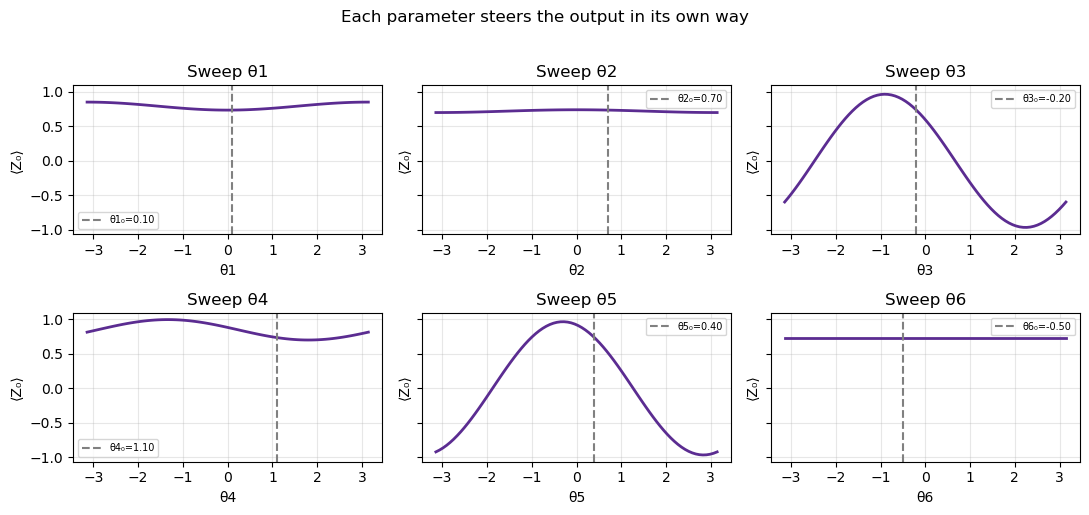

In [5]:
# ---- Activity 3.1: parameter sweep ----
x = np.array([0.6, -0.3])
base_theta = np.array([0.1, 0.7, -0.2, 1.1, 0.4, -0.5])

fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharey=True)
sweep = np.linspace(-np.pi, np.pi, 80)

for i, ax in enumerate(axes.flat):
    ys = []
    for v in sweep:
        th = base_theta.copy(); th[i] = v
        st = variational_circuit_2q(feature_map_2q(x), th)
        ys.append(expectation_Z0(st))
    ax.plot(sweep, ys, color='#5B2C91', lw=2)
    ax.axvline(base_theta[i], ls='--', color='gray', label=f'θ{i+1}₀={base_theta[i]:.2f}')
    ax.set_title(f"Sweep θ{i+1}"); ax.set_xlabel(f"θ{i+1}")
    ax.set_ylabel("⟨Z₀⟩"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.suptitle("Each parameter steers the output in its own way", y=1.02)
plt.tight_layout(); plt.show()

# TODO (try this on your own):
# Change `x` and re-run. Notice the curves shift - the *data*
# changes how each parameter affects the output. That's
# exactly why PQCs can learn data-dependent functions.

<details><summary>Reflection</summary>

If one θᵢ has *no effect* on the output for a given input, classical gradient descent has nothing to grip, gradient = 0. This is the **barren plateau** problem in QML: for too-deep random ansatzes, gradients vanish exponentially with circuit depth. Designing ansatzes that *avoid* barren plateaus is an active research area.
</details>

---
# Section 3.2-Variational Quantum Classifiers (VQCs)

## What is a variational algorithm?

A **variational algorithm** is just the hybrid loop from Section 3.1 with a clear job: minimize some cost function over the circuit parameters θ.

For a **classifier**, the four steps are:

1. **Prepare** a quantum state |ψ(x)⟩ that encodes input x.
2. **Apply** a parameterized circuit U(θ).
3. **Measure** to get a prediction ŷ(x, θ) (e.g. the sign of ⟨Z⟩).
4. **Loss**: compute L(θ) = Σ_i loss(y_i, ŷ(x_i, θ)) on training data, then have a classical optimizer update θ.

Repeat until L is small.

## Feature encoding-getting classical data *into* a quantum state

This is one of the most consequential design choices in QML. Three common strategies:

| Encoding | What you do | Pros | Cons |
|---|---|---|---|
| **Basis encoding** | Map bit-string x to |x⟩ | Exact; simple | Needs n qubits for n bits |
| **Amplitude encoding** | Store x as amplitudes of a state | log₂(N) qubits for N features | Hard to prepare |
| **Angle encoding** | x → rotation angles in Ry/Rz | Cheap; widely used | Limited expressivity |

The schematic from Section 3.1 used **angle encoding**: Ry(xᵢ) on qubit i.

## Why VQCs matter for AI

- They're **NISQ-friendly**- shallow circuits, classical optimizer carries the heavy lifting.
- They can sometimes represent functions a classical net of similar size cannot.
- Parameter counts can be tiny- useful for low-data regimes.
- They're the gateway architecture: quantum neural networks and quantum kernels are both refinements of the VQC idea.

### A complete worked example: classify points by their angle

We'll generate 2-D data where class is determined by whether the point is in the upper-right vs. lower-left quadrant, then train a VQC to distinguish them.

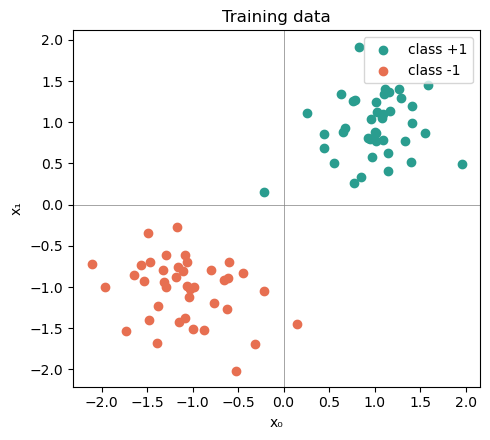

In [6]:
# Generate a 2-class dataset
def make_data(n=30, seed=1):
    rng = np.random.default_rng(seed)
    Xa = rng.normal(loc=( 1.0,  1.0), scale=0.45, size=(n//2, 2))
    Xb = rng.normal(loc=(-1.0, -1.0), scale=0.45, size=(n//2, 2))
    X = np.vstack([Xa, Xb])
    y = np.array([+1]*(n//2) + [-1]*(n//2))
    perm = rng.permutation(n)
    return X[perm], y[perm]

X_train, y_train = make_data(80, seed=1)
X_test,  y_test  = make_data(40, seed=2)

plt.figure(figsize=(5,4.5))
plt.scatter(X_train[y_train==+1, 0], X_train[y_train==+1, 1], color='#2A9D8F', label='class +1')
plt.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1], color='#E76F51', label='class -1')
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.legend(); plt.title("Training data"); plt.xlabel("x₀"); plt.ylabel("x₁")
plt.tight_layout(); plt.show()

Final train loss: 0.045
Test accuracy:   100.0%


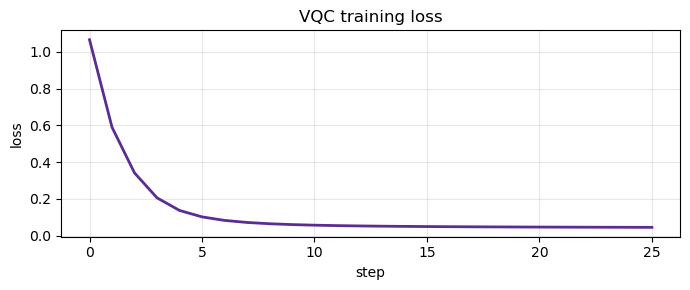

In [7]:
# VQC: feature map (angle encoding) + variational ansatz + <Z_0> output
def vqc_predict(x, theta):
    s = feature_map_2q(x)
    s = variational_circuit_2q(s, theta)
    return expectation_Z0(s)          # in [-1, +1]

def vqc_loss(theta, X, y):
    preds = np.array([vqc_predict(x, theta) for x in X])
    # squared loss against {+1, -1}
    return np.mean((preds - y)**2)

# Numerical-gradient optimizer (works in any environment, no autograd needed).
def numeric_grad(f, theta, eps=1e-3):
    g = np.zeros_like(theta)
    for i in range(len(theta)):
        t1 = theta.copy(); t1[i] += eps
        t2 = theta.copy(); t2[i] -= eps
        g[i] = (f(t1) - f(t2)) / (2*eps)
    return g

# Train
theta = np.random.uniform(-1, 1, size=6)
history = {'theta': [theta.copy()], 'loss': [vqc_loss(theta, X_train, y_train)]}
lr = 0.4
for step in range(25):
    g = numeric_grad(lambda th: vqc_loss(th, X_train, y_train), theta)
    theta = theta - lr * g
    history['theta'].append(theta.copy())
    history['loss'].append(vqc_loss(theta, X_train, y_train))

print(f"Final train loss: {history['loss'][-1]:.3f}")
preds_test = np.sign([vqc_predict(x, theta) for x in X_test])
acc = np.mean(preds_test == y_test)
print(f"Test accuracy:   {acc*100:.1f}%")

plt.figure(figsize=(7, 3))
plt.plot(history['loss'], color='#5B2C91', lw=2)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("VQC training loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Activity 3.2- Watch the decision boundary form

Here's the centerpiece interactivity for this chapter: we replay the training history and **animate the classifier's decision boundary** as parameters update. The boundary starts as a random tilt of color and gradually rotates into place to separate the two clusters.

In [9]:
# Build an animation of the decision boundary over training steps.
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 25), np.linspace(-2.5, 2.5, 25))
grid = np.c_[xx.ravel(), yy.ravel()]

# Pre-compute predictions at sampled checkpoints (keeps the animation light)
checkpoints = list(range(0, len(history['theta']), 4))
preds_frames = []
for k in checkpoints:
    th = history['theta'][k]
    p = np.array([vqc_predict(x, th) for x in grid]).reshape(xx.shape)
    preds_frames.append(p)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.contourf(xx, yy, preds_frames[0], levels=20, cmap='RdYlGn', vmin=-1, vmax=1)
sc_pos = ax.scatter(X_train[y_train==+1, 0], X_train[y_train==+1, 1],
                    edgecolor='black', facecolor='#2A9D8F', s=40, label='+1')
sc_neg = ax.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1],
                    edgecolor='black', facecolor='#E76F51', s=40, label='-1')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("x₀"); ax.set_ylabel("x₁"); ax.legend(loc='upper left')
title = ax.set_title("step 0")

def update(i):
    for coll in list(ax.collections):
        coll.remove()
    ax.contourf(xx, yy, preds_frames[i], levels=20, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.scatter(X_train[y_train==+1, 0], X_train[y_train==+1, 1],
               edgecolor='black', facecolor='#2A9D8F', s=40)
    ax.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1],
               edgecolor='black', facecolor='#E76F51', s=40)
    title.set_text(f"training step {checkpoints[i]}   loss={history['loss'][checkpoints[i]]:.3f}")
    return ()

anim = FuncAnimation(fig, update, frames=len(preds_frames), interval=300)
plt.close(fig)
HTML(anim.to_jshtml())

<details><summary>Try-it-yourself</summary>

In the cells above, change `make_data` to put the two classes along a *diagonal* (e.g. one at (1, -1) and another at (-1, 1)), or rotate one. Retrain. Does the VQC still find a good boundary? Does it take more steps?
</details>

---
# Section 3.3-Quantum Neural Networks

## What makes a neural network "quantum"?

A classical neural network is a chain of (linear transformation → nonlinearity → linear → nonlinearity → …). The nonlinearity (ReLU, sigmoid, tanh) is what gives a deep net its expressive power. Without it, the whole network collapses to one linear function.

A **Quantum Neural Network (QNN)** replaces those layers with quantum operations:

- **Layers** become parameterized unitaries U(θ).
- **Weights** become rotation angles.
- **Inputs** are encoded into a quantum state.
- **The nonlinearity** comes from *measurement*- the squared modulus |amplitude|² is a nonlinear function of the amplitude.

That last point is the key conceptual move. Quantum unitaries are all linear by definition, so there's no place inside the circuit for a ReLU. Instead, the act of measuring (or computing an expectation value, which involves |amplitudes|²) supplies the nonlinearity.

## Classical NN vs Quantum NN side-by-side

| | **Classical NN** | **Quantum NN** |
|---|---|---|
| Data representation | Vector of real numbers | Amplitudes of a quantum state |
| Layer operation | Wx + b (linear) | Parameterized unitary U(θ) |
| Nonlinearity | ReLU, sigmoid, tanh | Measurement / |·|² |
| Parameter count | Often millions-billions | Tens to thousands today |
| State space | ℝⁿ | ℂ^(2ⁿ) (exponentially bigger) |
| Hardware | GPU/TPU | NISQ device or simulator |
| Training | Backprop (autograd) | Parameter-shift rule, gradient-free, or hybrid autograd |

### Visual: information flow in a QNN

Below: a 3-qubit QNN with two variational "layers" separated by entangling CNOTs, ending in a measurement that produces a scalar output ŷ.

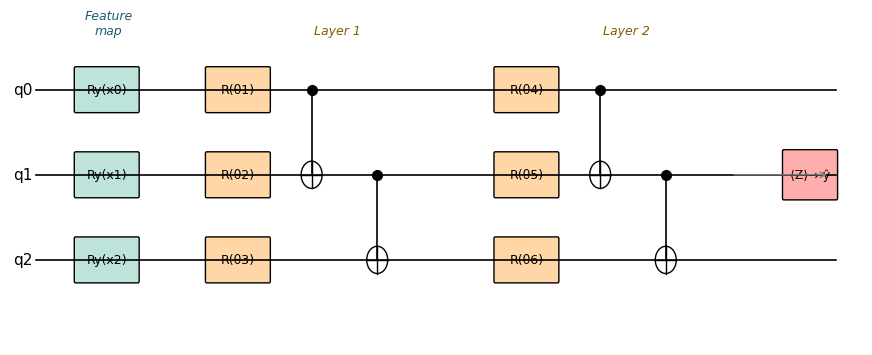

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.set_xlim(0, 13); ax.set_ylim(-0.8, 3); ax.axis('off')

def wire(y, lbl):
    ax.plot([0.4, 12.6], [y, y], color='black', lw=1.2)
    ax.text(0.05, y, lbl, va='center', fontsize=11)

wire(2.2, 'q0'); wire(1.2, 'q1'); wire(0.2, 'q2')

def gbox(x, y, w, h, t, c):
    ax.add_patch(patches.FancyBboxPatch((x, y-h/2), w, h, boxstyle="round,pad=0.02",
                                        facecolor=c, edgecolor='black', lw=1))
    ax.text(x+w/2, y, t, ha='center', va='center', fontsize=9)

# Encoding
for j, y in enumerate([2.2, 1.2, 0.2]):
    gbox(1.0, y, 0.95, 0.5, f'Ry(x{j})', '#bee3db')
ax.text(1.5, 2.85, 'Feature\nmap', ha='center', fontsize=9, style='italic', color='#1b5e6f')

# Layer 1
for j, y in enumerate([2.2, 1.2, 0.2]):
    gbox(3.0, y, 0.95, 0.5, f'R(θ{j+1})', '#ffd6a5')
# CNOT chain
for ctrl, tgt, y1, y2 in [(0,1,2.2,1.2),(1,2,1.2,0.2)]:
    x = 4.6 + (1.0 if ctrl==1 else 0)
    ax.plot([x,x],[y1,y2], color='black', lw=1.2)
    ax.plot(x, y1, marker='o', color='black', markersize=7)
    ax.add_patch(patches.Circle((x,y2), 0.16, facecolor='white', edgecolor='black'))
    ax.plot([x-0.16,x+0.16],[y2,y2], color='black', lw=1)
    ax.plot([x,x],[y2-0.16,y2+0.16], color='black', lw=1)
ax.text(5.0, 2.85, 'Layer 1', ha='center', fontsize=9, style='italic', color='#8a5a00')

# Layer 2
for j, y in enumerate([2.2, 1.2, 0.2]):
    gbox(7.4, y, 0.95, 0.5, f'R(θ{j+4})', '#ffd6a5')
for ctrl, tgt, y1, y2 in [(0,1,2.2,1.2),(1,2,1.2,0.2)]:
    x = 9.0 + (1.0 if ctrl==1 else 0)
    ax.plot([x,x],[y1,y2], color='black', lw=1.2)
    ax.plot(x, y1, marker='o', color='black', markersize=7)
    ax.add_patch(patches.Circle((x,y2), 0.16, facecolor='white', edgecolor='black'))
    ax.plot([x-0.16,x+0.16],[y2,y2], color='black', lw=1)
    ax.plot([x,x],[y2-0.16,y2+0.16], color='black', lw=1)
ax.text(9.4, 2.85, 'Layer 2', ha='center', fontsize=9, style='italic', color='#8a5a00')

# Measurement -> scalar output
gbox(11.8, 1.2, 0.8, 0.55, '⟨Z⟩→ ŷ', '#ffadad')
ax.annotate('', xy=(12.5, 1.2), xytext=(11.0, 1.2),
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.show()

### Code-along: build a 1-qubit QNN and compare to a classical neuron

A *single* qubit QNN already does interesting things. Below we compare:
- A classical **logistic neuron** y = σ(wx + b).
- A **1-qubit QNN** that encodes x by Ry(x) and learns rotations Rz(α), Ry(β) before measuring ⟨Z⟩.

Both are trained to fit the same noisy function. Watch the difference in shape.

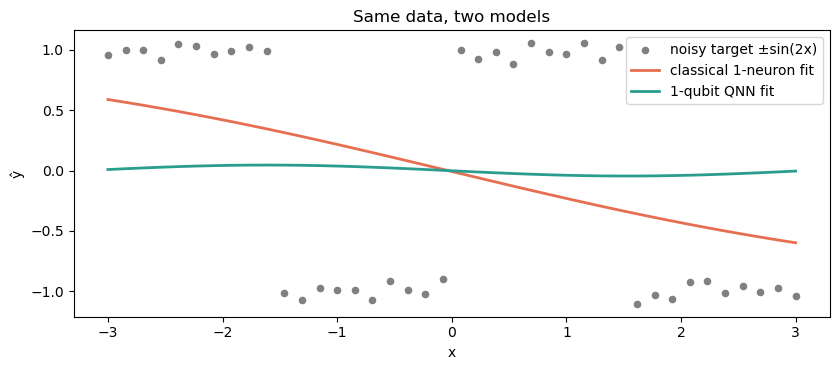

Notice the QNN can curve and oscillate; the single classical neuron is monotonic.


In [11]:
# Target function: a wavy curve harder to fit with one neuron
def target_fn(x):
    return np.sign(np.sin(2.0*x))    # +1 / -1

xs = np.linspace(-3, 3, 40)
ys = target_fn(xs) + 0.05*np.random.randn(len(xs))

# ----- Classical neuron -----
def sigmoid(z): return 1/(1+np.exp(-z))
def class_pred(x, w, b): return 2*sigmoid(w*x+b) - 1     # in [-1, 1]
def class_loss(p, X, Y): return np.mean((class_pred(X, *p) - Y)**2)

p = np.array([0.1, 0.0])
for _ in range(120):
    g = numeric_grad(lambda pp: class_loss(pp, xs, ys), p, eps=1e-3)
    p = p - 0.1*g
class_curve = class_pred(xs, *p)

# ----- 1-qubit QNN -----
def qnn_pred(x, theta):
    s = ket0(1)
    s = Ry(x) @ s
    s = Rz(theta[0]) @ s
    s = Ry(theta[1]) @ s
    s = Rz(theta[2]) @ s
    # <Z> on the single qubit
    return np.real(s.conj() @ (Z @ s))

def qnn_loss(theta, X, Y):
    return np.mean([(qnn_pred(x, theta)-y)**2 for x, y in zip(X, Y)])

th = np.random.uniform(-1, 1, size=3)
for _ in range(80):
    g = numeric_grad(lambda t: qnn_loss(t, xs, ys), th, eps=1e-3)
    th = th - 0.3*g
qnn_curve = np.array([qnn_pred(x, th) for x in xs])

# Plot
plt.figure(figsize=(8.5, 3.8))
plt.scatter(xs, ys, color='gray', s=20, label='noisy target ±sin(2x)')
plt.plot(xs, class_curve, color='#E76F51', lw=2, label='classical 1-neuron fit')
plt.plot(xs, qnn_curve, color='#2A9D8F', lw=2, label='1-qubit QNN fit')
plt.legend(); plt.xlabel("x"); plt.ylabel("ŷ"); plt.title("Same data, two models")
plt.tight_layout(); plt.show()
print("Notice the QNN can curve and oscillate; the single classical neuron is monotonic.")

### Activity 3.3- How does QNN depth change expressivity?

Re-train the QNN with **more layers** and see how the function it can fit gets richer.

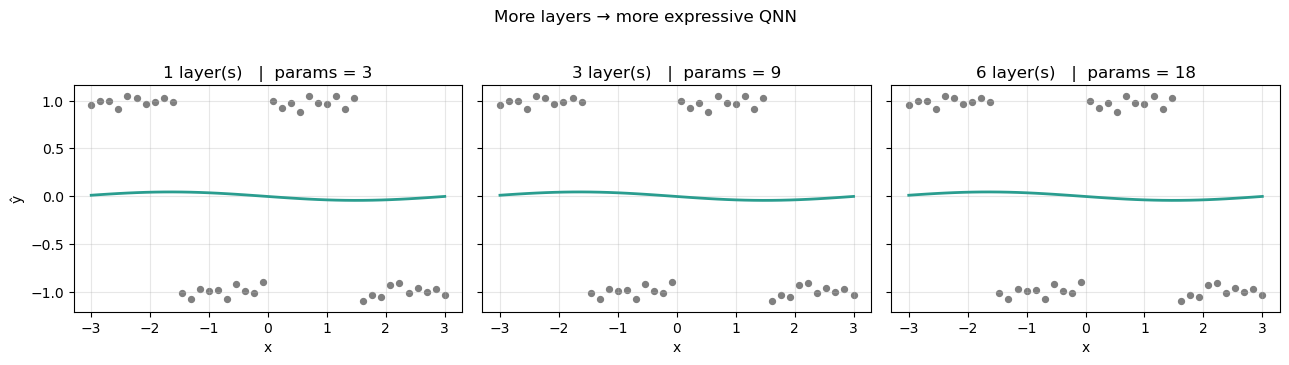

In [12]:
# ---- Activity 3.3: depth vs expressivity ----
def qnn_pred_layers(x, theta, L):
    """L-layer QNN: each layer is Rz, Ry, Rz on the one qubit (3*L params)."""
    s = ket0(1); s = Ry(x) @ s
    for l in range(L):
        s = Rz(theta[3*l+0]) @ s
        s = Ry(theta[3*l+1]) @ s
        s = Rz(theta[3*l+2]) @ s
    return np.real(s.conj() @ (Z @ s))

def fit_qnn(L, steps=80, lr=0.25):
    rng = np.random.default_rng(0)
    th = rng.uniform(-1, 1, size=3*L)
    for _ in range(steps):
        g = numeric_grad(lambda t: np.mean([(qnn_pred_layers(x, t, L)-y)**2
                                            for x, y in zip(xs, ys)]), th, eps=1e-3)
        th = th - lr*g
    return th

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, L in zip(axes, [1, 3, 6]):
    th = fit_qnn(L)
    curve = [qnn_pred_layers(x, th, L) for x in xs]
    ax.scatter(xs, ys, color='gray', s=18)
    ax.plot(xs, curve, color='#2A9D8F', lw=2)
    ax.set_title(f"{L} layer(s)   |  params = {3*L}")
    ax.set_xlabel("x"); ax.grid(alpha=0.3)
axes[0].set_ylabel("ŷ")
plt.suptitle("More layers → more expressive QNN", y=1.03)
plt.tight_layout(); plt.show()

---
# Section 3.4- Quantum Kernel Models

## Classical kernels in 30 seconds

A **kernel method** (like a Support Vector Machine) doesn't learn weights for raw features. Instead, it learns from a similarity matrix:

$$ K_{ij} = k(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle. $$

The function φ maps each data point into some (possibly very high-dimensional) **feature space**. The kernel trick is that we never have to compute φ(x) explicitly - we just need to compute the inner product k(x, x').

Common kernels: linear, polynomial, RBF (Gaussian).

## Quantum kernels

In a **quantum kernel**, the feature map is a quantum circuit:

$$ x \longmapsto |\phi(x)\rangle = U_{\phi}(x)|0\rangle. $$

The kernel is then the overlap of two such states:

$$ k(x, x') = |\langle \phi(x) | \phi(x') \rangle |^2. $$

Geometrically, two points are "similar" if their corresponding quantum states are close on the high-dimensional sphere. The big payoff: a quantum feature map can put data into a Hilbert space of dimension 2ⁿ, *exponentially* large-possibly making classes linearly separable that aren't classically separable with practical kernels.

## Quantum vs classical kernels

| | Classical kernel | Quantum kernel |
|---|---|---|
| Feature space | ℝᵈ (often via implicit RBF) | ℂ^(2ⁿ), exponentially large |
| Compute K(x,x') | Closed-form formula | Run a circuit, measure overlap |
| Trainable? | Usually fixed | Parameterized maps can be *trained* |
| Speedup vs classical | Generally none | Provable speedup on certain crafted tasks |

### Computing a quantum kernel matrix

We'll use the same 2-qubit angle encoding as a feature map, then compute the Gram matrix K[i,j] = |⟨φ(x_i)|φ(x_j)⟩|² on a tiny dataset.

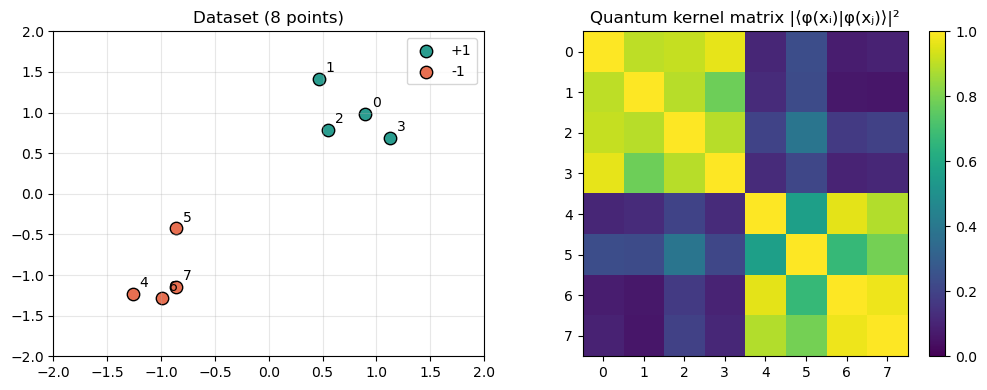

Block structure: same-class points are more similar than cross-class points.


In [13]:
def quantum_feature_state(x):
    """Angle-encode (x0, x1) on 2 qubits with a small extra entangling layer."""
    s = ket0(2)
    s = apply_1q(H, 0, 2) @ s        # superpose
    s = apply_1q(H, 1, 2) @ s
    s = apply_1q(Rz(x[0]), 0, 2) @ s
    s = apply_1q(Rz(x[1]), 1, 2) @ s
    s = apply_cnot(0, 1, 2) @ s
    s = apply_1q(Rz(x[0]*x[1]), 1, 2) @ s
    return s

def quantum_kernel(x, xp):
    a = quantum_feature_state(x)
    b = quantum_feature_state(xp)
    return abs(np.vdot(a, b))**2

# Tiny dataset: 4 points from class +1, 4 from -1
np.random.seed(2)
X_demo = np.vstack([np.random.normal((1, 1), 0.25, (4,2)),
                    np.random.normal((-1,-1), 0.25, (4,2))])

K = np.array([[quantum_kernel(xi, xj) for xj in X_demo] for xi in X_demo])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_demo[:4,0], X_demo[:4,1], color='#2A9D8F', s=80, edgecolor='black', label='+1')
axes[0].scatter(X_demo[4:,0], X_demo[4:,1], color='#E76F51', s=80, edgecolor='black', label='-1')
for i, p in enumerate(X_demo):
    axes[0].annotate(str(i), p, textcoords="offset points", xytext=(5,5))
axes[0].set_xlim(-2,2); axes[0].set_ylim(-2,2); axes[0].grid(alpha=0.3)
axes[0].legend(); axes[0].set_title("Dataset (8 points)")

im = axes[1].imshow(K, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title("Quantum kernel matrix |⟨φ(xᵢ)|φ(xⱼ)⟩|²")
axes[1].set_xticks(range(8)); axes[1].set_yticks(range(8))
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

print("Block structure: same-class points are more similar than cross-class points.")

### Activity 3.4- Quantum kernel SVM (conceptual)

Once we have a kernel matrix K, we can plug it into a kernel-based classifier. Here we build a *very* small kernel-ridge-style classifier by hand- no scikit-learn needed.

Given training kernel K and labels y, the classifier predicts

$$ \hat y(x_*) = \text{sign} \left( \sum_i \alpha_i \, k(x_*, x_i) \right), \quad \alpha = (K + \lambda I)^{-1} y. $$

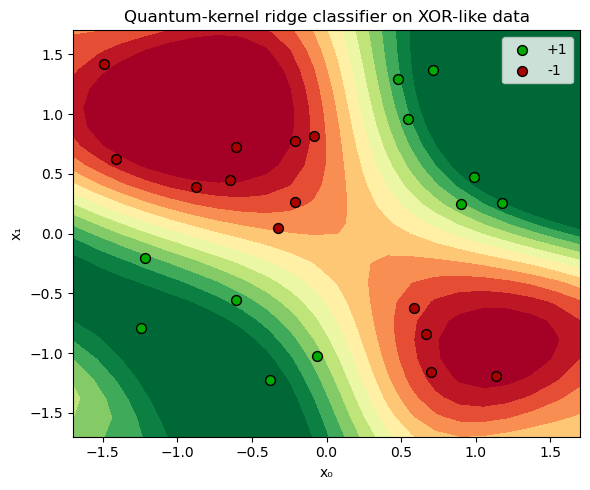

The quantum feature map lets a linear method classify a non-linearly-separable problem.


In [14]:
# ---- Activity 3.4 ----
# Generate a slightly larger dataset (XOR-like).
def make_xor(n=20, seed=3):
    rng = np.random.default_rng(seed)
    pts = []
    labs = []
    for _ in range(n):
        x = rng.uniform(-1.5, 1.5, size=2)
        y = +1 if x[0]*x[1] > 0 else -1
        pts.append(x); labs.append(y)
    return np.array(pts), np.array(labs)

X_xor, y_xor = make_xor(24)

# Build kernel matrix
n = len(X_xor)
K = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        K[i, j] = quantum_kernel(X_xor[i], X_xor[j])

lam = 0.05
alpha = np.linalg.solve(K + lam*np.eye(n), y_xor.astype(float))

# Predict on a grid
gx, gy = np.meshgrid(np.linspace(-1.7, 1.7, 22), np.linspace(-1.7, 1.7, 22))
grid = np.c_[gx.ravel(), gy.ravel()]
preds = np.array([sum(alpha[i]*quantum_kernel(p, X_xor[i]) for i in range(n))
                  for p in grid]).reshape(gx.shape)

plt.figure(figsize=(6,5))
plt.contourf(gx, gy, preds, levels=20, cmap='RdYlGn', vmin=-1, vmax=1)
plt.scatter(X_xor[y_xor==+1, 0], X_xor[y_xor==+1, 1], color='#0a0', edgecolor='black', s=50, label='+1')
plt.scatter(X_xor[y_xor==-1, 0], X_xor[y_xor==-1, 1], color='#a00', edgecolor='black', s=50, label='-1')
plt.title("Quantum-kernel ridge classifier on XOR-like data")
plt.xlabel("x₀"); plt.ylabel("x₁"); plt.legend()
plt.tight_layout(); plt.show()
print("The quantum feature map lets a linear method classify a non-linearly-separable problem.")

---
## Unit 3 Summary

A quick recap of the quantum ML toolkit:

| Concept | Key idea |
|---|---|
| **Hybrid loop** | A classical optimizer tunes a parameterized quantum circuit |
| **PQC / ansatz** | A quantum circuit whose rotation angles are trainable parameters |
| **Feature map** | How classical data gets encoded into a quantum state (angle, amplitude, basis) |
| **VQC** | Variational Quantum Classifier: a small quantum model trained end-to-end |
| **QNN nonlinearity** | Comes from measurement, since \|amplitude\|² is nonlinear in the amplitude |
| **Quantum kernel** | Similarity = overlap of two quantum states in a 2ⁿ-dim feature space |
| **Barren plateaus** | Gradients vanish exponentially in too-deep random ansatzes |

In the next unit, we shift from learning models to optimization: VQE, QAOA, and how to apply them to real AI problems.

---

---
# 📝 End-of-Unit Quiz

Try each question first, then click to reveal the answer.

## Section A-Multiple Choice

**1. In a hybrid quantum-classical algorithm, what runs on the classical computer?**

A) Nothing - everything is quantum.
B) The optimizer that updates the circuit parameters.
C) The qubit measurements.
D) Quantum gate applications.

<details><summary>Answer 1</summary>**B).** The classical computer runs the optimizer (Adam, SGD, COBYLA, etc.) and stores the current parameter values. The quantum computer evaluates the parameterized circuit and returns measurement outcomes.</details>

---

**2. A Parameterized Quantum Circuit (PQC) most closely plays the role of which classical ML component?**

A) The loss function.
B) The dataset.
C) A trainable model / neural network layer.
D) The optimizer.

<details><summary>Answer 2</summary>**C).** A PQC takes inputs and parameters and produces an output, just like a neural network layer. The rotation angles play the role of weights.</details>

---

**3. In a Variational Quantum Classifier, what provides the nonlinearity?**

A) The CNOT gates.
B) The classical optimizer.
C) Measurement / squared amplitudes |·|².
D) The feature encoding.

<details><summary>Answer 3</summary>**C).** All unitaries inside the circuit are linear; the nonlinearity enters when we compute probabilities or expectation values, which involve |amplitude|².</details>

---

**4. Why are quantum kernels potentially powerful?**

A) They run faster than RBF kernels on a GPU.
B) They map data into an exponentially large Hilbert space, which may make classes separable.
C) They eliminate the need for a training set.
D) They use no parameters at all.

<details><summary>Answer 4</summary>**B).** A 2ⁿ-dimensional feature space is exponentially big. Some problems are easy in such a space and hard in any practical classical kernel space.</details>

---

**5. Which encoding strategy uses *one rotation per feature* on a separate qubit?**

A) Amplitude encoding
B) Basis encoding
C) Angle encoding
D) Phase-flip encoding

<details><summary>Answer 5</summary>**C) Angle encoding.** Cheap to implement, widely used in VQC tutorials and on NISQ hardware.</details>

## Section B- Short Answer

**6. Why is the *hybrid* loop so important for current (NISQ) quantum hardware?**

<details><summary>Answer 6</summary>NISQ devices have shallow, noisy circuits and cannot run long pure-quantum algorithms reliably. Off-loading the optimization to a classical computer keeps the quantum part short - a few layers of gates - while still letting the model learn.</details>

---

**7. Name one practical drawback of amplitude encoding compared to angle encoding.**

<details><summary>Answer 7</summary>Amplitude encoding is exponentially compact (log₂N qubits for N features) but is hard to prepare: building an arbitrary 2ⁿ-amplitude state can require an exponentially deep circuit. Angle encoding is shallow but stores at most one feature per qubit.</details>

---

**8. In your own words, explain what a "barren plateau" is and why it threatens deep QNN training.**

<parameter name="answer8">Past a certain depth (or under random initialization in a too-flexible ansatz), the gradient of the loss with respect to every parameter becomes exponentially small in the number of qubits. The optimizer sees a flat landscape, and gradient descent stalls. This is why ansatz design - choosing structured, problem-specific circuits - is essential.</details>

---

**9. Suppose a 1-qubit QNN learns a fit, but a 4-layer QNN fits the same data much better. What concept explains this?**

<details><summary>Answer 9</summary>Expressivity. Each additional layer adds parameters and effectively widens the family of functions the QNN can represent. A 1-qubit single-rotation circuit can only express a limited class of single-variable functions of ⟨Z⟩; stacking layers lets it represent more complicated curves.</details>

---

**10. (Bonus) When would you reach for a quantum *kernel* method instead of a variational *neural* approach?**

<details><summary>Answer 10</summary>Kernel methods shine when the dataset is small and you want a provably-good geometric notion of similarity in a huge feature space. Variational QNN approaches scale better to large data because they don't need to store an N×N kernel matrix, but their training is harder and prone to barren plateaus. Kernels also have the advantage that, once you have K, you can use any kernel-based algorithm (SVM, ridge, kernel-PCA) on top.</details>

---


---
## End-of-unit submission

Fill in your quiz answers below, then run this cell to submit. Your answers and the fact that you finished Unit 3 are logged automatically. After your 5th completed unit, your certificate will be emailed to you.

In [ ]:
# ============================================================
# END-OF-UNIT SUBMISSION - fill in your answers below
# ============================================================

quiz_answers = {
    "q1": "",        # multiple choice: A, B, C, or D
    "q2": "",
    "q3": "",
    "q4": "",
    "q5": "",
    "q6_short_answer": "Type your answer to question 6 here.",
    "q7_short_answer": "Type your answer to question 7 here.",
    "q8_short_answer": "Type your answer to question 8 here.",
    "q9_short_answer": "Type your answer to question 9 here.",
    "q10_bonus":       "Type your bonus answer here, or leave blank."
}

reflection = "What did you find most interesting in this unit? (optional)"

_post_event("unit_completed",
            payload={"quiz": quiz_answers, "reflection": reflection})

print(f"Submitted Unit 3!")
print("If this was your 5th completed unit, watch your inbox for a certificate.")